# Notebook 03 – Deep Learning: a recurrent U-Net surrogate and how to judge it

Can a trained network replace the reservoir simulator in the many runs that forecasts and monitoring need? And how would I know whether its forecasts of pressure and CO₂ are good enough, during injection and after it stops (*shut-in*)?

My *surrogate* is a recurrent U-Net, an encoder–decoder for maps with a memory between report steps and physical rules built into its outputs. It would be judged against a refined numerical reference that estimates the converged solution, not only against the simulation it learned from. The examples check its shapes, its built-in constraints and that the boundary reaches every output; two toy studies show why the choice of reference matters and why uncertainty bands must cover whole trajectories.

This notebook covers WP3 of my research proposal (draft v0.6.3). The network is **not trained**, so its outputs are not predictions; training it is proposed future work.

**Labels used in this notebook**

- **My work:** my own earlier work in Deep Learning (implementations, exercises, analysis and explanations), summarised in §1.
- **Implemented example:** new code written for this notebook and run here on toy inputs or an untrained network, in a few seconds.
- **Proposed adaptation:** what I plan to do in the PhD; not done yet.
- **Evaluated result:** a tested research result. There are none yet.

## 1. My work in Deep Learning

*Label: My work (my own implementations).*

- **Seeded PyTorch training.** A `set_seed` helper fixes every random seed, so that a run can be repeated exactly; training loops with an optimiser and a loss.
- **CNNs** (convolutional neural networks, which slide small learned filters over a map), including a convolution written out from scratch, and how kernel size, stride and padding change the output shape.
- **U-Nets and transfer learning.** A U-Net is an encoder–decoder with skip connections, which pass fine detail from the encoder straight to the decoder. Transfer learning re-uses a pretrained network for a new task, here in an exercise adapted from the PyTorch transfer-learning tutorial (see references).
- **RNN and LSTM cells written from their equations.** Recurrent cells carry a memory from one step to the next; the LSTM does this with input, forget and output gates and a candidate update, the cell state carrying the memory. For text generation each prediction was fed back as the next input, which is a *rollout*.
- **Counting trainable parameters**, to keep the size of a model in view.

My original notebooks are not reproduced in this repository.

## 2. From my work to the CO₂ problem

*Label: proposed adaptation.*

Each method from my work, what it becomes in WP3, and what has to change:

| Method from my work | Use in WP3 | What has to change |
|---|---|---|
| LSTM cell from its equations | A ConvLSTM cell (§3): the same gates, with convolutions instead of linear layers | The memory is a map on the reservoir grid, and the injection rate enters at every step, including zero after shut-in |
| U-Net | Encoder–decoder for overpressure and saturation maps (§5) | The outputs must obey physics: saturation between 0 and 1, and a CO₂ inventory that adds up (§4). They must also be able to depend on the boundary condition, which enters as an input (§5.1) |
| Softmax output of a classifier | Splitting the injected CO₂ into four non-negative parts (§4) | The shares multiply a known mass, and the outflow share is fixed at zero for a closed boundary |
| Seeded training | Deep ensembles: the same network trained from different seeds | The spread between members is one uncertainty estimate; it is checked against conformal bands (§8) |
| Rollout | Forecasts step by step from the start of injection to [30] years after shut-in | Errors can grow with time, so accuracy and coverage are judged per time window and over whole trajectories (§8) |
| Transfer learning | Fine-tuning for a new boundary type or site with few runs | Only if the shift tests of Notebook 02 show that it is needed |

## 3. A ConvLSTM cell

*Label: implemented example (untrained).*

The network has to remember the state of the reservoir, its pressure and its plume, from one report step to the next. An LSTM cell (Hochreiter & Schmidhuber, 1997) keeps such a memory, the cell state $c$, and updates it with three *gates*, numbers between 0 and 1 that decide how much to add, keep and pass on. In a ConvLSTM cell (Shi et al., 2015) the linear layers are replaced by one convolution $*$, so the hidden state $h$ and the cell state $c$ are maps:

$$i = \sigma(W_i * [x_t, h_{t-1}]), \quad f = \sigma(W_f * [x_t, h_{t-1}]), \quad o = \sigma(W_o * [x_t, h_{t-1}]), \quad g = \tanh(W_g * [x_t, h_{t-1}])$$

$$c_t = f \odot c_{t-1} + i \odot g, \qquad h_t = o \odot \tanh(c_t)$$

Here $\sigma$ is the sigmoid function, which maps any number to a value between 0 and 1, and $\odot$ multiplies two maps cell by cell. The code uses the same gate names as my earlier LSTM cell.

The check below runs the cell for five steps on random maps. The two states keep the shape of the maps, and $|h|$ stays below 1 because $h = o \odot \tanh(c)$.

In the surrogate the maps are the reservoir grid, and the cell carries the state on through shut-in, when the injection rate is zero.

In [1]:
# import required libraries
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from scipy.stats import beta

In [2]:
class ConvLSTMCell(nn.Module):
    # LSTM cell in which the matrix products are replaced by one convolution

    def __init__(self, in_ch, hid_ch, k=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, k, padding=k // 2)    # all four gates in one convolution

    def forward(self, x, state):
        h, c = state
        gates = self.conv(torch.cat([x, h], dim=1))                             # apply the weights to input and previous state
        input_gate, forget_gate, output_gate, candidate_update = torch.split(gates, self.hid_ch, dim=1)
        c = torch.sigmoid(forget_gate) * c + torch.sigmoid(input_gate) * torch.tanh(candidate_update)
        h = torch.sigmoid(output_gate) * torch.tanh(c)
        return h, c

In [3]:
# Checking the cell on random maps: the shapes stay the same, and |h| < 1 because h = o * tanh(c)
torch.manual_seed(42)
cell = ConvLSTMCell(in_ch=3, hid_ch=8)
x = torch.randn(1, 3, 16, 16)                       # one sample, 3 input maps of 16 x 16 cells
h, c = torch.zeros(1, 8, 16, 16), torch.zeros(1, 8, 16, 16)
with torch.no_grad():
    for step in range(5):
        h, c = cell(x, (h, c))
print(f'hidden state {tuple(h.shape)}, cell state {tuple(c.shape)}, largest |h| = {h.abs().max():.3f}')

hidden state (1, 8, 16, 16), cell state (1, 8, 16, 16), largest |h| = 0.427


## 4. A softmax layer for the CO₂ inventory

*Label: implemented example.*

The surrogate must say where the injected CO₂ is (proposal §5):

$$M_\text{inj}(t) = M_\text{mob}(t) + M_\text{imm}(t) + M_\text{diss}(t) + M_\text{out}(t)$$

mobile, immobile, dissolved, and cumulative outflow across the edge of the model. The injected mass $M_\text{inj}(t)$ is known from the schedule, so the network only has to predict how it is **shared**. A *softmax*, as at the output of a classifier, turns four numbers (the *logits*) into four non-negative shares that add up to one. Multiplying by $M_\text{inj}(t)$ gives four masses that add up to $M_\text{inj}(t)$ exactly, so the mass balance holds by construction and training cannot break it; §6 checks what the layer does not guarantee.

For a closed boundary nothing can leave, so the outflow input is set to $-\infty$ before the softmax, which makes its share exactly zero.

The test below gives the layer equal inputs, so the shares must be equal: a third each for a closed boundary, whose outflow share is zero, and a quarter each for an open one, and the parts must add up to the injected mass exactly.

In [4]:
def inventory(logits, m_inj, closed):
    # Split the injected mass into mobile, immobile, dissolved and outflow; outflow share 0 if the boundary is closed
    # logits: (batch, time, 4); m_inj: (batch, time); closed: (batch,) True/False
    mask = torch.zeros_like(logits)
    mask[..., 3] = torch.where(closed, -torch.inf, 0.0)[:, None]     # -inf -> exp(-inf) = 0 in the softmax
    return torch.softmax(logits + mask, dim=-1) * m_inj[..., None]

In [5]:
# Known-answer test: equal inputs must give equal shares, 1/3 each for a closed boundary and 1/4 each for an open one
logits = torch.zeros(2, 3, 4)                           # 2 cases, 3 report steps, 4 parts
m_inj = torch.tensor([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0]])  # cumulative injected mass, e.g. Mt
closed = torch.tensor([True, False])
inv = inventory(logits, m_inj, closed)
print('closed boundary, last step (mobile, immobile, dissolved, outflow):', inv[0, -1].numpy().round(4))
print('open boundary,   last step (mobile, immobile, dissolved, outflow):', inv[1, -1].numpy().round(4))
print(f'largest |sum of parts - injected mass| = {(inv.sum(-1) - m_inj).abs().max():.1e}')

closed boundary, last step (mobile, immobile, dissolved, outflow): [1. 1. 1. 0.]
open boundary,   last step (mobile, immobile, dissolved, outflow): [0.75 0.75 0.75 0.75]
largest |sum of parts - injected mass| = 0.0e+00


## 5. The recurrent U-Net, untrained

*Label: implemented example (untrained network: shapes and built-in constraints only; its outputs are not predictions).*

Does the full network give the maps and series the proposal needs, with its physical constraints, and can its predictions depend on the boundary condition? To check, I build the network, pass random inputs through it and test its outputs. It combines the pieces above:

- **Encoder:** two levels of convolutions read four geology maps (for example log-permeability, porosity, caprock depth and thickness) on a 64 × 64 grid. Here they are random numbers.
- **Memory:** a ConvLSTM cell at the coarse level carries the state from one report step to the next. Two extra maps enter at every step: the injection rate, so shut-in is simply a rate of zero, and the boundary openness (below).
- **Decoder:** an up-sampling layer and a skip connection from the encoder, as in a U-Net (Ronneberger et al., 2015), give two maps per step: overpressure, and CO₂ saturation through a sigmoid, so that it stays between 0 and 1.
- **Series head:** a small linear layer reads the averaged memory and gives the injector pressure, the average overpressure and the four inventory logits, which go through the softmax layer of §4.

**The boundary as an input.** The lateral boundary strongly controls pressure after shut-in (Notebook 01 §3), so the maps and the series must be able to depend on it. Here it is one number per case, the **openness** $b$: 0 for a closed (no-flow) boundary, 1 for an open boundary that lets brine leave, and a value in between for a semi-closed boundary. It enters the memory as a constant map at every step, so every cell sees it at once and its effect does not have to travel in from the edge through the convolutions. In this example the same number also sets the hard constraint of §4: when $b = 0$ the outflow share is fixed at zero. How $b$ and that constraint would be set in the PhD is described in §11.

The inputs below have 6 report steps: injection for 4 steps, then 2 steps after shut-in. $M_\text{inj}$ grows by one unit per injection step and then stays constant. Case 0 has a closed boundary ($b = 0$) and case 1 an open one ($b = 1$).

In [6]:
class RecurrentUNet(nn.Module):

    def __init__(self, in_ch=4, base=16):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(in_ch, base, 3, padding=1), nn.ReLU())
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), nn.Conv2d(base, 2 * base, 3, padding=1), nn.ReLU())
        self.cell = ConvLSTMCell(2 * base + 2, 2 * base)          # +2 channels: injection rate and boundary openness
        self.up = nn.ConvTranspose2d(2 * base, base, 2, stride=2)
        self.dec = nn.Sequential(nn.Conv2d(2 * base, base, 3, padding=1), nn.ReLU(), nn.Conv2d(base, 2, 1))
        self.head = nn.Linear(2 * base, 2 + 4)                    # injector pressure, mean overpressure, 4 inventory logits

    def forward(self, geo, rate, m_inj, openness):
        # openness: (batch,) boundary openness b; 0 = closed, 1 = open, in between = semi-closed
        B, T = rate.shape
        s1 = self.enc1(geo)                                       # fine level (kept for the skip connection)
        s2 = self.enc2(s1)                                        # coarse level
        b_map = openness.view(B, 1, 1, 1).expand(-1, 1, *s2.shape[-2:])   # the boundary as a constant map
        h, c = torch.zeros_like(s2), torch.zeros_like(s2)
        fields, scalars, logits = [], [], []
        for t in range(T):                                        # rollout over the report steps
            r = rate[:, t].view(B, 1, 1, 1).expand(-1, 1, *s2.shape[-2:])
            h, c = self.cell(torch.cat([s2, r, b_map], dim=1), (h, c))   # rate and boundary enter at every step
            out = self.dec(torch.cat([self.up(h), s1], dim=1))    # skip connection
            dp, sg = out[:, 0], torch.sigmoid(out[:, 1])          # overpressure; saturation kept in [0, 1]
            z = self.head(h.mean(dim=(2, 3)))
            fields.append(torch.stack([dp, sg], 1))
            scalars.append(z[:, :2])
            logits.append(z[:, 2:])
        inv = inventory(torch.stack(logits, 1), m_inj, closed=(openness == 0))   # hard constraint from the same input
        return torch.stack(fields, 1), torch.stack(scalars, 1), inv

def count_trainable_parameters(model):
    return sum([p.numel() for p in model.parameters() if p.requires_grad])

In [7]:
# Step 1: build the network with a fixed seed and make the inputs
torch.manual_seed(42)
model = RecurrentUNet()
geo = torch.randn(2, 4, 64, 64)                             # 2 cases, 4 geology maps, 64 x 64 cells
rate = torch.tensor([[1.0] * 4 + [0.0] * 2] * 2)            # injection for 4 steps, then shut-in
m_inj = torch.cumsum(rate, 1)                               # cumulative injected mass: 1, 2, 3, 4, 4, 4
openness = torch.tensor([0.0, 1.0])                         # case 0 closed (b = 0), case 1 open (b = 1)
closed = openness == 0                                      # used by the checks below

# Step 2: one forward pass, without gradients (nothing is trained here)
with torch.no_grad():
    fields, scalars, inv = model(geo, rate, m_inj, openness)

print(f'fields {tuple(fields.shape)} = (cases, steps, [overpressure, saturation], 64, 64)')
print(f'series {tuple(scalars.shape)} = (cases, steps, [injector pressure, average overpressure])')
print(f'inventory {tuple(inv.shape)} = (cases, steps, [mobile, immobile, dissolved, outflow])')
print(f'The model has {count_trainable_parameters(model):,} trainable parameters')

fields (2, 6, 2, 64, 64) = (cases, steps, [overpressure, saturation], 64, 64)
series (2, 6, 2) = (cases, steps, [injector pressure, average overpressure])
inventory (2, 6, 4) = (cases, steps, [mobile, immobile, dissolved, outflow])
The model has 88,312 trainable parameters


In [8]:
# Step 3: the constraints that hold whatever the weights are
print(f'saturation between {fields[:, :, 1].min():.3f} and {fields[:, :, 1].max():.3f} (must be within 0 and 1)')
print(f'largest |sum of the four parts - injected mass| = {(inv.sum(-1) - m_inj).abs().max():.1e}')
print(f'smallest part: {inv.min():.1e} (must not be negative)')
print(f'largest outflow, closed case: {inv[0, :, 3].max():.1e}; open case: {inv[1, :, 3].max():.2f}')

saturation between 0.451 and 0.563 (must be within 0 and 1)
largest |sum of the four parts - injected mass| = 4.8e-07
smallest part: 0.0e+00 (must not be negative)
largest outflow, closed case: 0.0e+00; open case: 1.01


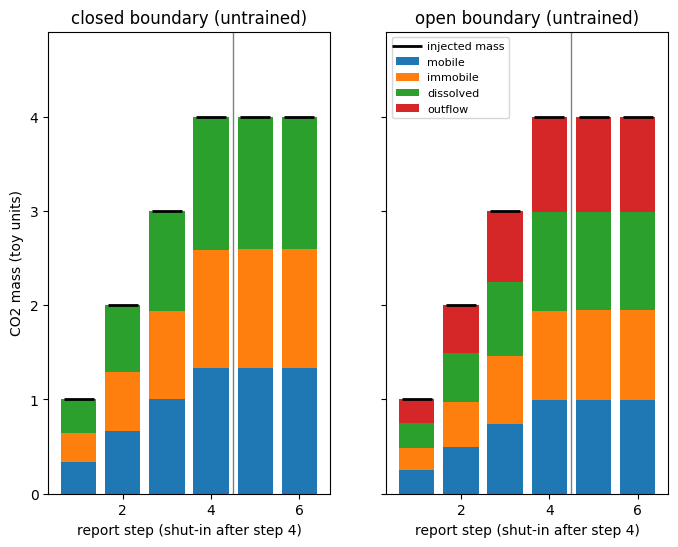

In [9]:
# Plot the untrained inventory for both cases as stacked bars
names = ['mobile', 'immobile', 'dissolved', 'outflow']
steps = np.arange(1, 7)
fig, ax = plt.subplots(1, 2, figsize=(8, 6), sharey=True)
for case, title in [(0, 'closed boundary'), (1, 'open boundary')]:
    bottom = np.zeros(6)
    for part in range(4):
        ax[case].bar(steps, inv[case, :, part].numpy(), bottom=bottom, label=names[part])
        bottom += inv[case, :, part].numpy()
    ax[case].plot(steps, m_inj[case].numpy(), 'k_', markersize=22, mew=2, label='injected mass')
    ax[case].axvline(4.5, color='grey', lw=1)
    ax[case].set_title(f'{title} (untrained)')
    ax[case].set_xlabel('report step (shut-in after step 4)')
ax[0].set_ylabel('CO2 mass (toy units)')
ax[0].set_ylim(0, 4.9)
ax[1].legend(fontsize=8);

#### How to read this result:

- The shapes are what the proposal needs: overpressure and saturation maps at every step (for P3, M2 and M3), and series for the injector pressure, the average overpressure and the four inventory terms (P1, P2, P4 and M1). The network has 88,312 trainable parameters; the boundary map adds 1,152 of them, all in the memory cell.
- Saturation stays between 0 and 1, the four parts add up to the injected mass to within $5\times10^{-7}$ (single-precision round-off), no part is negative, and the closed case has exactly zero outflow. These hold for any weights, so training cannot break them.
- The shares in the plot are almost equal (about a third each for the closed case, a quarter for the open case) because the network is untrained: it knows nothing yet about CO₂. The plot shows the structure, not a prediction.

Note: saturation and overpressure are also stored as maps, and dissolved and trapped CO₂ cannot be read from a saturation map alone. That is why the inventory comes from the series head, and why §6 checks whether the maps and the series agree.

One network therefore gives all seven decision quantities of the proposal in one rollout, and its constraints hold whatever it learns.

### 5.1 Does the boundary input reach the maps and the pressure?

*Label: implemented example (untrained network).*

Does changing the boundary change the predicted maps and pressure, or only the inventory? This is a controlled check: the same geology maps and the same injection history for three cases, and only the boundary openness changes, from closed ($b = 0$) to semi-closed ($b = 0.5$) and open ($b = 1$). If the boundary were used only in the inventory layer, the maps and the pressure series of the three cases would be identical.

In [10]:
# Controlled check: one geology and one injection history; only the boundary input changes
torch.manual_seed(0)
geo_one = torch.randn(1, 4, 64, 64).repeat(3, 1, 1, 1)      # the same geology maps for three cases
rate_3 = torch.tensor([[1.0] * 4 + [0.0] * 2] * 3)          # the same injection history
m_inj_3 = torch.cumsum(rate_3, 1)
openness_3 = torch.tensor([0.0, 0.5, 1.0])                  # closed, semi-closed, open

# the inputs differ only in the boundary
assert all(torch.equal(geo_one[0], geo_one[i]) and torch.equal(rate_3[0], rate_3[i]) for i in (1, 2))

with torch.no_grad():
    f3, s3, inv3 = model(geo_one, rate_3, m_inj_3, openness_3)   # the same untrained network as above

for case, name in [(1, 'semi-closed'), (2, 'open')]:
    print(f'{name} minus closed, largest change over all steps and cells:')
    print(f'   overpressure map {(f3[case, :, 0] - f3[0, :, 0]).abs().max():.4f}, '
          f'saturation map {(f3[case, :, 1] - f3[0, :, 1]).abs().max():.4f}')
    print(f'   injector pressure {(s3[case, :, 0] - s3[0, :, 0]).abs().max():.4f}, '
          f'average overpressure {(s3[case, :, 1] - s3[0, :, 1]).abs().max():.4f}')
changed = ((f3[2, -1, 0] - f3[0, -1, 0]).abs() > 1e-6).float().mean()
print(f'share of cells whose overpressure changes between open and closed at the last step: {changed:.2f}')
print('outflow at the last step (closed, semi-closed, open):', inv3[:, -1, 3].numpy().round(4))
print(f'largest |sum of parts - injected mass| = {(inv3.sum(-1) - m_inj_3).abs().max():.1e}')

semi-closed minus closed, largest change over all steps and cells:
   overpressure map 0.0026, saturation map 0.0008
   injector pressure 0.0028, average overpressure 0.0095
open minus closed, largest change over all steps and cells:
   overpressure map 0.0050, saturation map 0.0015
   injector pressure 0.0061, average overpressure 0.0184
share of cells whose overpressure changes between open and closed at the last step: 1.00
outflow at the last step (closed, semi-closed, open): [0.     1.0118 1.0085]
largest |sum of parts - injected mass| = 2.4e-07


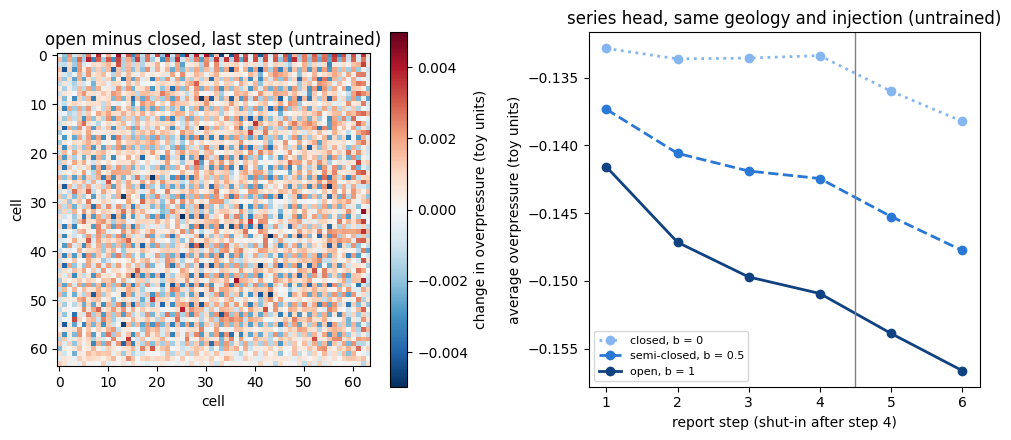

In [11]:
# Plot where the overpressure map changes, and the average-overpressure series of the three cases
colours = ['#86b6ef', '#2a78d6', '#104281']                 # light to dark blue: closed, semi-closed, open
styles = [':', '--', '-']
fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
diff = (f3[2, -1, 0] - f3[0, -1, 0]).numpy()
lim = np.abs(diff).max()
im = ax[0].imshow(diff, cmap='RdBu_r', vmin=-lim, vmax=lim)  # white = no change
fig.colorbar(im, ax=ax[0], label='change in overpressure (toy units)')
ax[0].set_title('open minus closed, last step (untrained)')
ax[0].set_xlabel('cell')
ax[0].set_ylabel('cell')
for case, name in enumerate(['closed, b = 0', 'semi-closed, b = 0.5', 'open, b = 1']):
    ax[1].plot(steps, s3[case, :, 1].numpy(), styles[case], color=colours[case], marker='o', lw=2, label=name)
ax[1].axvline(4.5, color='grey', lw=1)
ax[1].set_xlabel('report step (shut-in after step 4)')
ax[1].set_ylabel('average overpressure (toy units)')
ax[1].set_title('series head, same geology and injection (untrained)')
ax[1].legend(fontsize=8)
fig.tight_layout();

#### How to read this result:

- With the geology and the injection history held fixed, changing only the boundary changes every output: the overpressure map (by up to 0.0050 between open and closed), the saturation map (0.0015), the injector pressure (0.0061) and the average overpressure (0.0184). The change reaches every cell of the map (share 1.00), because the openness enters the memory as a constant map.
- The changes are small because the weights are random, and their size and sign mean nothing. In this run the open case happens to give the lowest average overpressure, as physics would suggest, but with random weights that order is a coincidence.
- The hard constraints still hold in all three cases: the parts add up to the injected mass to within $3\times10^{-7}$, the closed case has exactly zero outflow, and the semi-closed and open cases may have outflow.

So the network *can* now represent a boundary effect in its maps and series. Whether it learns the right one is a question for training on simulations with different boundaries, and for the boundary-type shift of Notebook 02 (hypothesis H2).

## 6. Two checks on the network's CO₂ bookkeeping

*Label: implemented example.*

The softmax layer guarantees non-negative parts and an exact total. It does not guarantee that the predicted maps and the predicted inventory agree, or that the cumulative outflow behaves physically, so these two things are checked:

1. **Free-phase mass from the maps.** Free CO₂ ($M_\text{mob} + M_\text{imm}$, the CO₂ held as a separate phase rather than dissolved) comes from the series head, but it can also be computed from the predicted maps: the sum over cells of porosity × saturation × CO₂ density × cell volume, with porosity $\phi(p) = \phi_\text{ref}[1 + c_r(p - p_\text{ref})]$ as in proposal §5. The two are not forced to agree; the mismatch is reported (proposal §6 WP3).
2. **Outflow never decreases.** $M_\text{out}$ is cumulative, so it can only grow. After shut-in $M_\text{inj}$ is constant, so any fall in the outflow share would make $M_\text{out}$ fall. The check also confirms zero outflow for a closed boundary and flags outflow above [0.1 %] of the injected mass, the domain-size flag of proposal §5.

As in Notebook 01, each check is first tested on cases with a known answer.

In [12]:
# Grid and rock values for the toy maps: round numbers, not a real site
cell_area = 100.0 * 100.0     # m2 per cell
thickness = 20.0              # m
phi_ref = 0.25                # porosity at the initial pressure
c_r = 5e-10                   # rock compressibility, 1/Pa
rho_co2 = 700.0               # CO2 density, kg/m3 (constant here; from the fluid tables in the PhD)

def free_phase_mass(dp_mpa, sg):
    # Free-phase CO2 mass (Mt) in each map: sum over cells of porosity x saturation x density x cell volume
    phi = phi_ref * (1 + c_r * dp_mpa * 1e6)                   # porosity at the local overpressure
    kg = (phi * sg * rho_co2 * cell_area * thickness).sum(axis=(-2, -1))
    return kg / 1e9                                            # kg -> Mt

In [13]:
# Known-answer test: a block of 10 x 20 cells with saturation 0.4 and overpressure 2 MPa, nothing elsewhere
dp_test = np.zeros((64, 64)); sg_test = np.zeros((64, 64))
dp_test[20:30, 20:40] = 2.0
sg_test[20:30, 20:40] = 0.4
exact = 200 * phi_ref * (1 + c_r * 2e6) * 0.4 * rho_co2 * cell_area * thickness / 1e9   # 200 cells, by hand
computed = free_phase_mass(dp_test, sg_test)
print(f'exact {exact:.6f} Mt, computed {computed:.6f} Mt, relative error {abs(computed - exact) / exact:.1e}')

# Seeded mismatch: series that claim 0.1 Mt more free CO2 than the maps hold must give a mismatch of -0.1 Mt
series_free = exact + 0.1
print(f'seeded mismatch, maps - series = {computed - series_free:+.3f} Mt')

exact 2.802800 Mt, computed 2.802800 Mt, relative error 3.2e-16
seeded mismatch, maps - series = -0.100 Mt


In [14]:
# The same diagnostic on the untrained network, last report step (M_inj = 4 units, read here as Mt)
maps_free = free_phase_mass(fields[:, -1, 0].numpy().astype(float), fields[:, -1, 1].numpy().astype(float))
series_free = (inv[:, -1, 0] + inv[:, -1, 1]).numpy()
for case, name in [(0, 'closed'), (1, 'open')]:
    print(f'{name:6s} case: free CO2 from the maps {maps_free[case]:6.1f} Mt, from the series {series_free[case]:.2f} Mt, '
          f'mismatch {(maps_free[case] - series_free[case]) / m_inj[case, -1]:+.1f} x injected mass')

closed case: free CO2 from the maps   72.3 Mt, from the series 2.60 Mt, mismatch +17.4 x injected mass
open   case: free CO2 from the maps   72.3 Mt, from the series 1.95 Mt, mismatch +17.6 x injected mass


In [15]:
def check_outflow(m_out, m_inj, closed, flag_share=0.001):
    # Three checks on cumulative outflow; m_out and m_inj: (cases, steps); closed: (cases,)
    never_decreases = np.all(np.diff(m_out, axis=1) >= -1e-6, axis=1)
    zero_if_closed = np.where(closed, np.all(m_out == 0, axis=1), True)
    flagged = m_out[:, -1] / m_inj[:, -1] > flag_share         # more than 0.1 % of the injected mass has left
    return never_decreases, zero_if_closed, flagged

# Known-answer tests: a correct series passes; a seeded decrease after shut-in is caught
good = np.array([[0.0, 0.01, 0.02, 0.03, 0.035, 0.036]])
bad = np.array([[0.0, 0.01, 0.02, 0.03, 0.028, 0.036]])      # falls at step 5
m_test = np.array([[1.0, 2.0, 3.0, 4.0, 4.0, 4.0]])
print('correct series :', check_outflow(good, m_test, np.array([False]))[0])
print('seeded decrease:', check_outflow(bad, m_test, np.array([False]))[0])

# The untrained network
dec, zero, flag = check_outflow(inv[:, :, 3].numpy(), m_inj.numpy(), closed.numpy())
print(f'untrained network: never decreases {dec}, zero if closed {zero}, flagged above 0.1 % {flag}')
print('open-case outflow by step:', inv[1, :, 3].numpy().round(4))

correct series : [ True]
seeded decrease: [False]
untrained network: never decreases [ True False], zero if closed [ True  True], flagged above 0.1 % [False  True]
open-case outflow by step: [0.2514 0.5035 0.7567 1.0107 1.0085 1.0086]


#### How to read this result:

- The free-phase function returns the hand-calculated mass of the test block (2.8028 Mt) to round-off, including the small porosity increase from the 2 MPa overpressure, and the seeded mismatch comes out as exactly −0.100 Mt. So the diagnostic can be trusted before it is used.
- On the untrained network the maps hold 72.3 Mt of free CO₂ in both cases when only 4 Mt was injected, because random weights put a saturation of about 0.5 in every cell. The number means nothing about a trained model. What matters is that the maps and the series are compared independently and the mismatch is reported, never forced to zero.
- The outflow check passes the correct series and catches the seeded decrease. It also catches the untrained network: in the open case the cumulative outflow falls from 1.0107 at the last injection step to 1.0085 after shut-in, which is impossible for a cumulative quantity. Nothing in the softmax layer prevents such a fall, so the check has to report it. The open case is also flagged, since about a quarter of the injected mass (1.01 of 4) is counted as outflow.

Note: the failure above comes from random weights. If the outflow check fails often after training, the outflow can be predicted as non-negative increments that are added up over time, which makes a fall impossible. This is an option, not yet part of the design.

After training, a large mismatch marks a forecast whose maps and series disagree, and a falling outflow marks one that breaks physics; both are flagged before the forecast is used.

## 7. Two kinds of accuracy

*Label: implemented example (toy numbers).*

Against what should a surrogate's accuracy be judged: the simulation it learned from, or the converged solution of the model equations? A surrogate $S$ is trained on the production-grid reference $R_h$ (the simulation on the grid used for the whole ensemble), which has its own discretisation error. In the PhD the converged solution is estimated by a refined numerical reference $R_\infty$ (Notebook 01 §6), and the surrogate's error against it is (proposal §7)

$$S - R_\infty = \underbrace{(S - R_h)}_{e_\text{sur}} + \underbrace{(R_h - R_\infty)}_{e_\text{num}}$$

In the toy below the converged value is known exactly, so here $R_\infty$ is the exact answer, which is how the code and the plot label it. There are 200 test realisations of one decision quantity:

- $R_\infty$ varies with the geology;
- the production grid adds a discretisation error of about $+0.8$ ($e_\text{num}$);
- the surrogate reproduces $R_h$ closely (error 0.3);
- a physics estimate, such as an analytic solution, is not trained on $R_h$: it has no bias but more scatter (0.6).

In [16]:
# Calculating the error of each method against the reference and against the exact answer
rng = np.random.default_rng(42)
R = 200
R_inf = rng.normal(10, 2, R)                     # exact answer of the model equations
e_num = 0.8 + 0.1 * rng.normal(size=R)           # discretisation error of the production grid
R_h = R_inf + e_num                              # the reference the surrogate is trained on
S = R_h + rng.normal(0, 0.3, R)                  # surrogate: close to the reference
P = R_inf + rng.normal(0, 0.6, R)                # physics estimate: not trained on R_h, unbiased but noisy

def rmse(err):
    return np.sqrt(np.mean(err**2))

print(f'against the reference R_h:   surrogate {rmse(S - R_h):.2f}, physics estimate {rmse(P - R_h):.2f}')
print(f'against the exact answer:    surrogate {rmse(S - R_inf):.2f}, physics estimate {rmse(P - R_inf):.2f}')
print(f'mean discretisation error e_num = {e_num.mean():.2f}')

against the reference R_h:   surrogate 0.30, physics estimate 1.03
against the exact answer:    surrogate 0.85, physics estimate 0.61
mean discretisation error e_num = 0.80


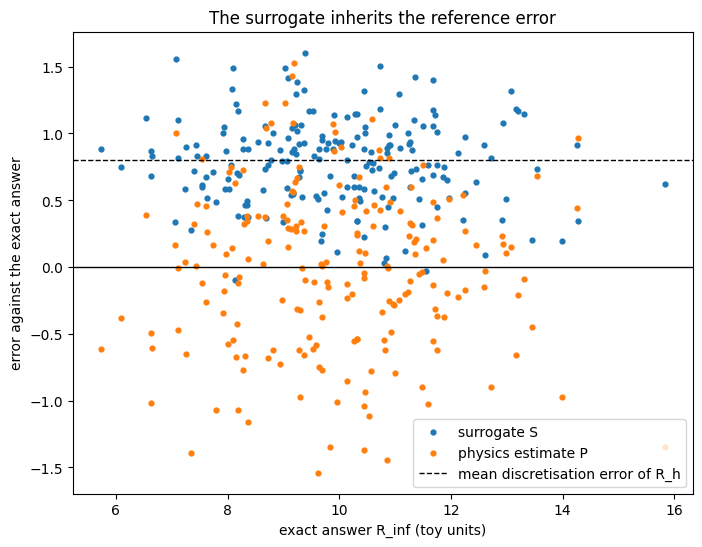

In [17]:
# Plot the errors against the exact answer
plt.figure(figsize=(8, 6))
plt.scatter(R_inf, S - R_inf, s=12, label='surrogate S')
plt.scatter(R_inf, P - R_inf, s=12, label='physics estimate P')
plt.axhline(0, color='k', lw=1)
plt.axhline(e_num.mean(), color='k', ls='--', lw=1, label='mean discretisation error of R_h')
plt.xlabel('exact answer R_inf (toy units)')
plt.ylabel('error against the exact answer')
plt.title('The surrogate inherits the reference error')
plt.legend();

#### How to read this result:

- Against the reference, the surrogate looks more than three times better than the physics estimate (0.30 against 1.03).
- Against the exact answer the order reverses: the physics estimate is better (0.61 against 0.85). In the plot the surrogate's errors sit in a band around +0.8, the discretisation error it learned from $R_h$, while the physics estimate scatters around zero. The surrogate's total error is close to $\sqrt{0.8^2 + 0.1^2 + 0.3^2} \approx 0.86$.

This is rule R2 of the proposal: an advantage seen only against $R_h$, and smaller than $|e_\text{num}|$, is not claimed. It is also why WP1 measures $e_\text{num}$ on a refinement subset (Notebook 01) before WP3 compares methods.

Note: here $e_\text{num}$ is known for every toy realisation. In the PhD it is measured only on the refined realisations. For the others it is estimated from that subset, and the estimate is an error indicator, not a bound: it is first checked on refined realisations held out for the purpose, and a verdict that rests on it is reported as provisional (proposal §7, rule R3).

## 8. Coverage over whole trajectories

*Label: implemented example (toy residuals).*

A pressure limit must hold for the whole monitoring period, so a forecast band is useful only if it contains the reference over the **whole** post-shut-in trajectory. *Conformal prediction* sets the width of a band from the errors on calibration realisations, so that a chosen share of new cases falls inside it, without assuming a shape for the errors.

In the toy, the residual (reference minus prediction) of each realisation over 12 report steps has two parts:

- a shared part, the same at every step, for example from a wrong permeability (standard deviation 1.0);
- a part that changes from step to step (standard deviation 0.4).

Bands are calibrated on 50 realisations and tested on 200, at a nominal level of 0.90 (the share each band is designed to contain), and the whole experiment is repeated 1000 times:

- **row-pooled** split conformal (Lei et al., 2018): one half-width from all calibration rows, realisations and steps mixed;
- **realisation-block** conformal (Lei, Rinaldo & Wasserman, 2015): each calibration realisation gives one score, its largest residual over the trajectory, which gives a simultaneous band.

I report *average* coverage (the share of all realisation–step values inside the band) and *trajectory* coverage (the share of realisations inside the band at every step).

In [18]:
T, alpha = 12, 0.10     # report steps; 1 - nominal level

def make_residuals(rng, n_real):
    # shared part (whole trajectory) + part that changes from step to step
    return rng.normal(0, 1.0, size=(n_real, 1)) + rng.normal(0, 0.4, size=(n_real, T))

def conformal_q(scores):
    # the k-th smallest calibration score, k = ceil((n + 1)(1 - alpha))
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.sort(scores)[min(k, n) - 1]

In [19]:
# Calculating average and trajectory coverage over 1000 repeats
results = {'row-pooled': [], 'realisation-block': []}
for rep in range(1000):
    rng = np.random.default_rng(rep)
    cal, test = make_residuals(rng, 50), make_residuals(rng, 200)
    q_row = conformal_q(np.abs(cal).ravel())             # every calibration value is a score
    q_block = conformal_q(np.abs(cal).max(axis=1))        # one score per calibration realisation
    for name, q in [('row-pooled', q_row), ('realisation-block', q_block)]:
        inside = np.abs(test) <= q
        results[name].append((inside.mean(), inside.all(axis=1).mean(), 2 * q))

for name, v in results.items():
    v = np.array(v)
    print(f'{name:18s}: average coverage {v[:, 0].mean():.3f}, trajectory coverage {v[:, 1].mean():.3f} '
          f'(5-95 % over repeats {np.percentile(v[:, 1], 5):.3f}-{np.percentile(v[:, 1], 95):.3f}), band width {v[:, 2].mean():.2f}')

row-pooled        : average coverage 0.895, trajectory coverage 0.716 (5-95 % over repeats 0.585-0.840), band width 3.53
realisation-block : average coverage 0.970, trajectory coverage 0.901 (5-95 % over repeats 0.815-0.965), band width 4.77


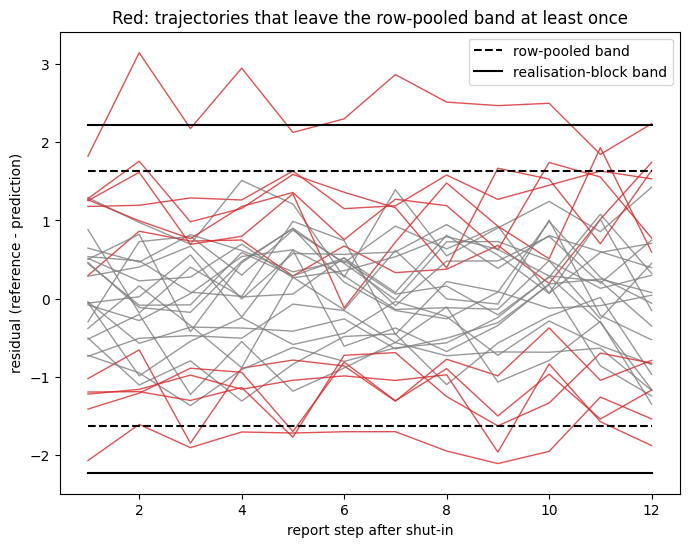

In [20]:
# Plot 30 test trajectories from the first repeat with both bands
rng = np.random.default_rng(0)
cal, test = make_residuals(rng, 50), make_residuals(rng, 200)
q_row, q_block = conformal_q(np.abs(cal).ravel()), conformal_q(np.abs(cal).max(axis=1))
steps = np.arange(1, T + 1)

plt.figure(figsize=(8, 6))
for traj in test[:30]:
    leaves = np.any(np.abs(traj) > q_row)
    plt.plot(steps, traj, color='tab:red' if leaves else 'tab:grey', lw=1, alpha=0.8)
for q, style, name in [(q_row, '--', 'row-pooled band'), (q_block, '-', 'realisation-block band')]:
    plt.plot(steps, np.full(T, q), 'k' + style, label=name)
    plt.plot(steps, np.full(T, -q), 'k' + style)
plt.xlabel('report step after shut-in')
plt.ylabel('residual (reference - prediction)')
plt.title('Red: trajectories that leave the row-pooled band at least once')
plt.legend();

In [21]:
# The decision rule of proposal §7: with 75 test realisations, when is the 0.90 target missed?
def clopper_pearson(k, n, conf=0.95):
    lo = beta.ppf((1 - conf) / 2, k, n - k + 1) if k > 0 else 0.0
    hi = beta.ppf(1 - (1 - conf) / 2, k + 1, n - k) if k < n else 1.0
    return lo, hi

n = 75
missed = [k for k in range(n + 1) if clopper_pearson(k, n)[1] < 0.90]
print(f'target missed when {max(missed)} or fewer of {n} realisations are fully covered')
for k in [61, 62, 68]:
    lo, hi = clopper_pearson(k, n)
    print(f'{k} of {n} fully covered: estimate {k / n:.3f}, 95 % interval {lo:.3f}-{hi:.3f}')

target missed when 61 or fewer of 75 realisations are fully covered
61 of 75 fully covered: estimate 0.813, 95 % interval 0.707-0.894
62 of 75 fully covered: estimate 0.827, 95 % interval 0.722-0.904
68 of 75 fully covered: estimate 0.907, 95 % interval 0.817-0.962


#### How to read this result:

- The row-pooled band looks right on average (0.895 against the nominal 0.90), but only 0.716 of realisations stay inside it for the whole trajectory. The shared part of the error moves a whole trajectory up or down, so the same realisations are missed again and again. In the plot these are the red curves.
- The realisation-block band keeps trajectory coverage at 0.901 on average, because it is calibrated on whole trajectories. The price is width: 4.77 against 3.53, about 1.35 times wider.
- Even when the method is right, a single test set can fall short: in 5 % of the repeats the block band's trajectory coverage was below 0.815. So with 75 test realisations the proposal counts the target as missed only when the whole Clopper–Pearson interval (an exact interval for a proportion) lies below 0.90, that is, when 61 or fewer realisations are fully covered (last cell).

This is why the proposal's target is trajectory coverage of at least 0.90, not average coverage (§9).

Note: here calibration and test realisations come from the same distribution, which is what the conformal guarantee needs. After a change of shut-in time or boundary type this no longer holds, which is what hypothesis H4 tests.

## 9. How WP3 will be evaluated

*Label: proposed adaptation. Values in square brackets are set with the supervisor before any results exist.*

The toy checks of §§3–8 become tests for the trained surrogate:

| Test | Question | Rule |
|---|---|---|
| **U1** accuracy | Is the surrogate accurate enough for a decision quantity? | R3: the 90th percentile of $\lvert S - R_\infty\rvert$ below [0.2] $u_\text{geo}$, per shift factor and time window, over test realisations whose numerical error was measured; under a shift, these must be refined cases of that shift. Otherwise only a provisional verdict (proposal §7) |
| **U2** added value | Is it better than the best simpler method, at the same tuning budget? | R1: paired comparison over test realisations (Notebook 02 §7); R2: against $R_\infty$ (§7 above) |
| **U3** cost | Is it cheaper overall, training data included, than a coarse-grid simulation equally accurate against $R_\infty$? | Total CPU and GPU hours, reported |
| **U4** ranking | Does it rank the Case B schedules as the reference does? | Same order of the constant, stepped and early-shut-in schedules for each decision quantity |
| Coverage | Do the bands contain whole trajectories? | Trajectory coverage of at least 0.90 from shut-in to [30] years after; missed if the whole Clopper–Pearson interval is below 0.90 |
| Bookkeeping | Do the maps and series agree? | Free-phase mismatch reported; outflow never decreases, is zero wherever the boundary representation lets no CO₂ cross (§11), and is flagged above [0.1 %] |

Every test is reported before and after shut-in (rule R5). The output of WP3 is $e_\text{sur}$, the coverage, and a statement of where the surrogate is fit for use (proposal §6).

## 10. Training plan

*Label: proposed adaptation. Text only: nothing is trained in this notebook.*

1. **Data.** TRAIN and SELECT geologies from the WP2 design (Notebook 02 §5): full histories through injection and shut-in, with maps and series at every report step, the boundary openness of each case as an input (§5.1), and its boundary representation, which sets the outflow constraint (§11).
2. **Scaling.** Inputs and outputs scaled with statistics from the training realisations only.
3. **Loss.** Errors in the maps (overpressure, saturation) plus errors in the series (injector pressure, average overpressure, the four inventory parts), with weights chosen on SELECT realisations. The inventory total needs no penalty term, because the softmax layer holds it exactly.
4. **Seeds.** Every run starts from `set_seed`, as in my earlier work; [5] members trained from different seeds form the deep ensemble (Lakshminarayanan et al., 2017).
5. **Rollout.** Trained on whole sequences and tested by rolling out from the start of injection to [30] years after shut-in, without resetting the memory.
6. **Use of the sets.** Early stopping and tuning on SELECT only; CALIB only for the conformal bands; the TEST geologies with their paired SHIFT and COMPOUND cases, and the AUDIT geologies, scored once, after all choices are frozen.
7. **Budget.** The number of tuning trials is the same as for the baselines of Notebook 02 §7, and GPU hours are reported (U3).

## 11. Assumptions and what has to change

- The network is untrained. Nothing here shows that it can learn the reference; only its shapes and built-in constraints are checked.
- A 64 × 64 map with one memory level is a stand-in. The real grid, the vertical structure and the number of report steps will set the architecture.
- The response to the boundary input in §5.1 comes from random weights. It shows that the input reaches every output, not that the response is right. The right response has to be learned from simulations with different boundaries, and it is tested on the boundary-type shift of Notebook 02, which hypothesis H2 expects to be hard.
- The boundary is one number per case here. In the PhD, $b$ would be the boundary parameter that the simulator itself uses, scaled to between 0 and 1: for example the strength of an analytic aquifer attached to the edge, or the pore-volume multiplier of the boundary cells. A boundary that is sealed along one part and open along another, such as a partly sealing fault, needs a map of openness along the edge.
- The zero-outflow constraint of §4 will follow the boundary representation, not $b$. Openness says how easily brine leaves; whether CO₂, free or dissolved, can cross depends on how the boundary is represented. If the chosen representation lets brine leave but no CO₂, the outflow share is fixed at zero even when $b > 0$. What each OPM Flow boundary option lets through is still to be confirmed.
- In §8 calibration and test residuals come from the same distribution. Real shut-in and boundary shifts break this, and the toy does not test it.
- The free-phase diagnostic uses a constant CO₂ density. In the PhD, density and $\phi(p)$ come from the same tables as the simulator, and the diagnostic is first checked on the simulator's own outputs (Notebook 01 §4.3).
- The series head is the only source of dissolved and trapped CO₂ (§5). Its errors are measured against the simulator's inventory outputs.

## 12. Status

**Run here:** the implemented examples of §§3–8: the memory cell, the inventory layer, the untrained network with its boundary check, the bookkeeping checks, and two toy studies of accuracy and coverage. **Proposed for the PhD:** training, deep ensembles and the usefulness tests U1–U4 on simulations (§§9–10). **My work:** summarised in §1. **Research results:** none yet.

## References and further reading

- Clopper, C. J. & Pearson, E. S. (1934). The use of confidence or fiducial limits illustrated in the case of the binomial. *Biometrika* 26(4), 404–413.
- Hochreiter, S. & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation* 9(8), 1735–1780.
- Lakshminarayanan, B., Pritzel, A. & Blundell, C. (2017). Simple and scalable predictive uncertainty estimation using deep ensembles. *Advances in Neural Information Processing Systems* 30.
- Lei, J., G'Sell, M., Rinaldo, A., Tibshirani, R. J. & Wasserman, L. (2018). Distribution-free predictive inference for regression. *Journal of the American Statistical Association* 113(523), 1094–1111.
- Lei, J., Rinaldo, A. & Wasserman, L. (2015). A conformal prediction approach to explore functional data. *Annals of Mathematics and Artificial Intelligence* 74(1), 29–43.
- Nordbotten, J. M., Fernø, M. A., Flemisch, B., Kovscek, A. R. & Lie, K.-A. (2024). The 11th Society of Petroleum Engineers Comparative Solution Project: problem definition. *SPE Journal* 29(05), 2507–2524. (Definitions of mobile, immobile and dissolved CO₂.)
- PyTorch Tutorials. Transfer learning for computer vision tutorial. https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html (the basis of my transfer-learning exercise, §1).
- Ronneberger, O., Fischer, P. & Brox, T. (2015). U-Net: convolutional networks for biomedical image segmentation. In *Medical Image Computing and Computer-Assisted Intervention – MICCAI 2015*, LNCS 9351, 234–241.
- Shi, X., Chen, Z., Wang, H., Yeung, D.-Y., Wong, W.-K. & Woo, W.-C. (2015). Convolutional LSTM network: a machine learning approach for precipitation nowcasting. *Advances in Neural Information Processing Systems* 28, 802–810.